# TREC-DL attack table (LaTeX)

This notebook reads `attack_table.csv` and writes `attack_table.tex`. It keeps all model rows, but presents only **Default** (the normal evaluator prompt) and **Defense** (the marker-aware evaluator prompt) columns. Each populated cell is rendered as `ASR%` and `successes/valid`.

The generated table requires `booktabs`, `makecell`, `multirow`, and `graphicx` in the manuscript preamble.

In [11]:
import csv
import re
import statistics
from collections import defaultdict
from pathlib import Path

try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = None
    display = None


def find_repository_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'LLM_prompt_attack').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the repository.')


def latex_escape(value):
    return (
        value.replace('\\', r'\textbackslash{}')
        .replace('&', r'\&')
        .replace('%', r'\%')
        .replace('_', r'\_')
        .replace('#', r'\#')
    )


METRIC = re.compile(r'^(?P<rate>\d+(?:\.\d+)?)% \((?P<success>\d+)/(?P<valid>\d+)\)$')
GROUPS = (
    ('Pairwise Flipped %', r'Pairwise Flipped \%'),
    ('Setwise Attack Success %', r'Setwise Attack Success \%'),
    ('Listwise Attack Top Position %', r'Listwise Attack Top Position \%'),
)
ATTACKS = ('DOH', 'DCH')
MODES = (('Default', 'Ours'), ('Defense', 'Defense'))


def column_name(group, attack, source):
    return f'{group} | {attack} | {source}'


def parse_metric(value):
    match = METRIC.match((value or '').strip())
    if match is None:
        return None
    return float(match['rate']), match['success'], match['valid']


def latex_metric(value):
    parsed = parse_metric(value)
    if parsed is None:
        return '--'
    rate, success, valid = parsed
    return rf'\makecell[c]{{{rate:.2f}\%\\[-1pt]\scriptsize({success}/{valid})}}'


def latex_summary(rows, column):
    values = [parsed[0] for row in rows if (parsed := parse_metric(row.get(column)))]
    if not values:
        return '--'
    if len(values) == 1:
        return rf'{values[0]:.2f}\%'
    return rf'{statistics.mean(values):.2f}\% $\pm$ {statistics.stdev(values):.2f}'


root = find_repository_root()
csv_path = root / 'Results' / 'attack_table.csv'
tex_path = root / 'Results' / 'attack_table.tex'

with csv_path.open(encoding='utf-8', newline='') as csv_file:
    rows = list(csv.DictReader(csv_file))

datasets = defaultdict(list)
for row in rows:
    if row['Model'].startswith('Mean'):
        continue
    datasets[row['Dataset']].append(row)

lines = [
    r'\begin{table*}[t]',
    r'\centering',
    r'\small',
    r'\setlength{\tabcolsep}{3pt}',
    r'\caption{Attack success rates for back-position injection on TREC-DL 2019 and 2020. Parentheses denote successes / valid outputs. Default uses the normal evaluator prompt; Defense uses the marker-aware evaluator prompt.}',
    r'\label{tab:trec-dl-attacks}',
    r'\resizebox{\textwidth}{!}{%',
    r'\begin{tabular}{ll*{12}{c}}',
    r'\toprule',
    r' & \textbf{Model} & \multicolumn{4}{c}{\textbf{Pairwise Flipped \%}} & \multicolumn{4}{c}{\textbf{Setwise Attack Success \%}} & \multicolumn{4}{c}{\textbf{Listwise Attack Top Position \%}} \\',
    r'\cmidrule(lr){3-6} \cmidrule(lr){7-10} \cmidrule(lr){11-14}',
    r' & & \multicolumn{2}{c}{DOH} & \multicolumn{2}{c}{DCH} & \multicolumn{2}{c}{DOH} & \multicolumn{2}{c}{DCH} & \multicolumn{2}{c}{DOH} & \multicolumn{2}{c}{DCH} \\',
    r' & & Default & Defense & Default & Defense & Default & Defense & Default & Defense & Default & Defense & Default & Defense \\',
    r'\midrule',
]

for dataset_index, (dataset, dataset_rows) in enumerate(datasets.items()):
    for row_index, row in enumerate(dataset_rows):
        cells = []
        if row_index == 0:
            cells.append(rf'\multirow{{{len(dataset_rows) + 1}}}{{*}}{{\rotatebox{{90}}{{{latex_escape(dataset)}}}}}')
        else:
            cells.append('')
        cells.append(latex_escape(row['Model']))
        for group, _display in GROUPS:
            for attack in ATTACKS:
                for _mode, source in MODES:
                    cells.append(latex_metric(row.get(column_name(group, attack, source))))
        lines.append(' & '.join(cells) + r' \\')

    summary_cells = ['', r'\textbf{Mean $\pm$ Std}']
    for group, _display in GROUPS:
        for attack in ATTACKS:
            for _mode, source in MODES:
                summary_cells.append(latex_summary(dataset_rows, column_name(group, attack, source)))
    lines.append(r'\midrule')
    lines.append(' & '.join(summary_cells) + r' \\')
    if dataset_index != len(datasets) - 1:
        lines.append(r'\midrule')

lines.extend([r'\bottomrule', r'\end{tabular}', r'}', r'\end{table*}'])
latex_table = '\n'.join(lines) + '\n'
tex_path.write_text(latex_table, encoding='utf-8')

print(f'Wrote {tex_path.relative_to(root)}')
if display is None:
    print(latex_table)
else:
    display(Markdown(f'```latex\n{latex_table}\n```'))


Wrote Results\attack_table.tex


```latex
\begin{table*}[t]
\centering
\small
\setlength{\tabcolsep}{3pt}
\caption{Attack success rates for back-position injection on TREC-DL 2019 and 2020. Parentheses denote successes / valid outputs. Default uses the normal evaluator prompt; Defense uses the marker-aware evaluator prompt.}
\label{tab:trec-dl-attacks}
\resizebox{\textwidth}{!}{%
\begin{tabular}{ll*{12}{c}}
\toprule
 & \textbf{Model} & \multicolumn{4}{c}{\textbf{Pairwise Flipped \%}} & \multicolumn{4}{c}{\textbf{Setwise Attack Success \%}} & \multicolumn{4}{c}{\textbf{Listwise Attack Top Position \%}} \\
\cmidrule(lr){3-6} \cmidrule(lr){7-10} \cmidrule(lr){11-14}
 & & \multicolumn{2}{c}{DOH} & \multicolumn{2}{c}{DCH} & \multicolumn{2}{c}{DOH} & \multicolumn{2}{c}{DCH} & \multicolumn{2}{c}{DOH} & \multicolumn{2}{c}{DCH} \\
 & & Default & Defense & Default & Defense & Default & Defense & Default & Defense & Default & Defense & Default & Defense \\
\midrule
\multirow{13}{*}{\rotatebox{90}{TREC-DL-2019}} & Qwen3-1.7B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Qwen3-4B & \makecell[c]{81.74\%\\[-1pt]\scriptsize(3348/4096)} & \makecell[c]{69.95\%\\[-1pt]\scriptsize(2865/4096)} & \makecell[c]{76.37\%\\[-1pt]\scriptsize(3128/4096)} & \makecell[c]{10.89\%\\[-1pt]\scriptsize(446/4096)} & \makecell[c]{86.49\%\\[-1pt]\scriptsize(3522/4072)} & \makecell[c]{73.60\%\\[-1pt]\scriptsize(3013/4094)} & -- & \makecell[c]{30.18\%\\[-1pt]\scriptsize(1233/4086)} & \makecell[c]{32.15\%\\[-1pt]\scriptsize(1316/4093)} & -- & -- & -- \\
 & Qwen3-8B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Qwen3-14B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Qwen3-32B & \makecell[c]{95.90\%\\[-1pt]\scriptsize(3928/4096)} & \makecell[c]{29.03\%\\[-1pt]\scriptsize(1189/4096)} & \makecell[c]{96.97\%\\[-1pt]\scriptsize(3972/4096)} & \makecell[c]{16.19\%\\[-1pt]\scriptsize(663/4096)} & \makecell[c]{90.10\%\\[-1pt]\scriptsize(3658/4060)} & \makecell[c]{79.74\%\\[-1pt]\scriptsize(3266/4096)} & -- & -- & \makecell[c]{53.11\%\\[-1pt]\scriptsize(1709/3218)} & -- & -- & -- \\
 & Gemma-3-12B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Gemma-3-27B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Llama-3-8B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Llama-3.3-70B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & GPT-4.1-mini & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & GPT-OSS-20B & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4060/4060)} & \makecell[c]{33.37\%\\[-1pt]\scriptsize(1300/3896)} & -- & -- & \makecell[c]{98.99\%\\[-1pt]\scriptsize(98/99)} & \makecell[c]{17.06\%\\[-1pt]\scriptsize(676/3963)} & -- & -- & -- & -- & -- & -- \\
 & gpt-5.6-terra & -- & -- & -- & -- & \makecell[c]{8.00\%\\[-1pt]\scriptsize(8/100)} & -- & -- & -- & -- & -- & -- & -- \\
\midrule
 & \textbf{Mean $\pm$ Std} & 92.55\% $\pm$ 9.58 & 44.12\% $\pm$ 22.48 & 86.67\% $\pm$ 14.57 & 13.54\% $\pm$ 3.75 & 70.89\% $\pm$ 42.26 & 56.80\% $\pm$ 34.55 & -- & 30.18\% & 42.63\% $\pm$ 14.82 & -- & -- & -- \\
\midrule
\multirow{13}{*}{\rotatebox{90}{TREC-DL-2020}} & Qwen3-1.7B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Qwen3-4B & \makecell[c]{80.64\%\\[-1pt]\scriptsize(3303/4096)} & \makecell[c]{67.33\%\\[-1pt]\scriptsize(2758/4096)} & \makecell[c]{73.34\%\\[-1pt]\scriptsize(3004/4096)} & \makecell[c]{15.31\%\\[-1pt]\scriptsize(627/4096)} & \makecell[c]{83.80\%\\[-1pt]\scriptsize(3420/4081)} & \makecell[c]{72.04\%\\[-1pt]\scriptsize(2950/4095)} & -- & -- & \makecell[c]{31.11\%\\[-1pt]\scriptsize(1271/4086)} & -- & \makecell[c]{80.60\%\\[-1pt]\scriptsize(3298/4092)} & -- \\
 & Qwen3-8B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Qwen3-14B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Qwen3-32B & \makecell[c]{92.11\%\\[-1pt]\scriptsize(3773/4096)} & \makecell[c]{28.25\%\\[-1pt]\scriptsize(1157/4096)} & \makecell[c]{95.24\%\\[-1pt]\scriptsize(3901/4096)} & \makecell[c]{18.43\%\\[-1pt]\scriptsize(755/4096)} & \makecell[c]{87.87\%\\[-1pt]\scriptsize(3572/4065)} & \makecell[c]{77.29\%\\[-1pt]\scriptsize(3166/4096)} & -- & -- & \makecell[c]{53.54\%\\[-1pt]\scriptsize(1679/3136)} & -- & -- & -- \\
 & Gemma-3-12B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Gemma-3-27B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Llama-3-8B & \makecell[c]{60.11\%\\[-1pt]\scriptsize(2462/4096)} & \makecell[c]{56.59\%\\[-1pt]\scriptsize(2318/4096)} & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Llama-3.3-70B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & GPT-4.1-mini & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & GPT-OSS-20B & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4080/4080)} & \makecell[c]{37.09\%\\[-1pt]\scriptsize(1433/3864)} & -- & -- & \makecell[c]{99.68\%\\[-1pt]\scriptsize(4035/4048)} & \makecell[c]{15.64\%\\[-1pt]\scriptsize(618/3952)} & -- & -- & -- & -- & -- & -- \\
 & meta.llama3-70b-instruct-v1:0 & \makecell[c]{97.80\%\\[-1pt]\scriptsize(4006/4096)} & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
\midrule
 & \textbf{Mean $\pm$ Std} & 86.13\% $\pm$ 16.37 & 47.31\% $\pm$ 17.84 & 84.29\% $\pm$ 15.49 & 16.87\% $\pm$ 2.21 & 90.45\% $\pm$ 8.25 & 54.99\% $\pm$ 34.18 & -- & -- & 42.33\% $\pm$ 15.86 & -- & 80.60\% & -- \\
\bottomrule
\end{tabular}
}
\end{table*}

```

## Default versus defense bar charts

This block plots every available Default and Defense result in two figures: one for DOH and one for DCH. Missing runs are omitted rather than represented as zero-height bars.

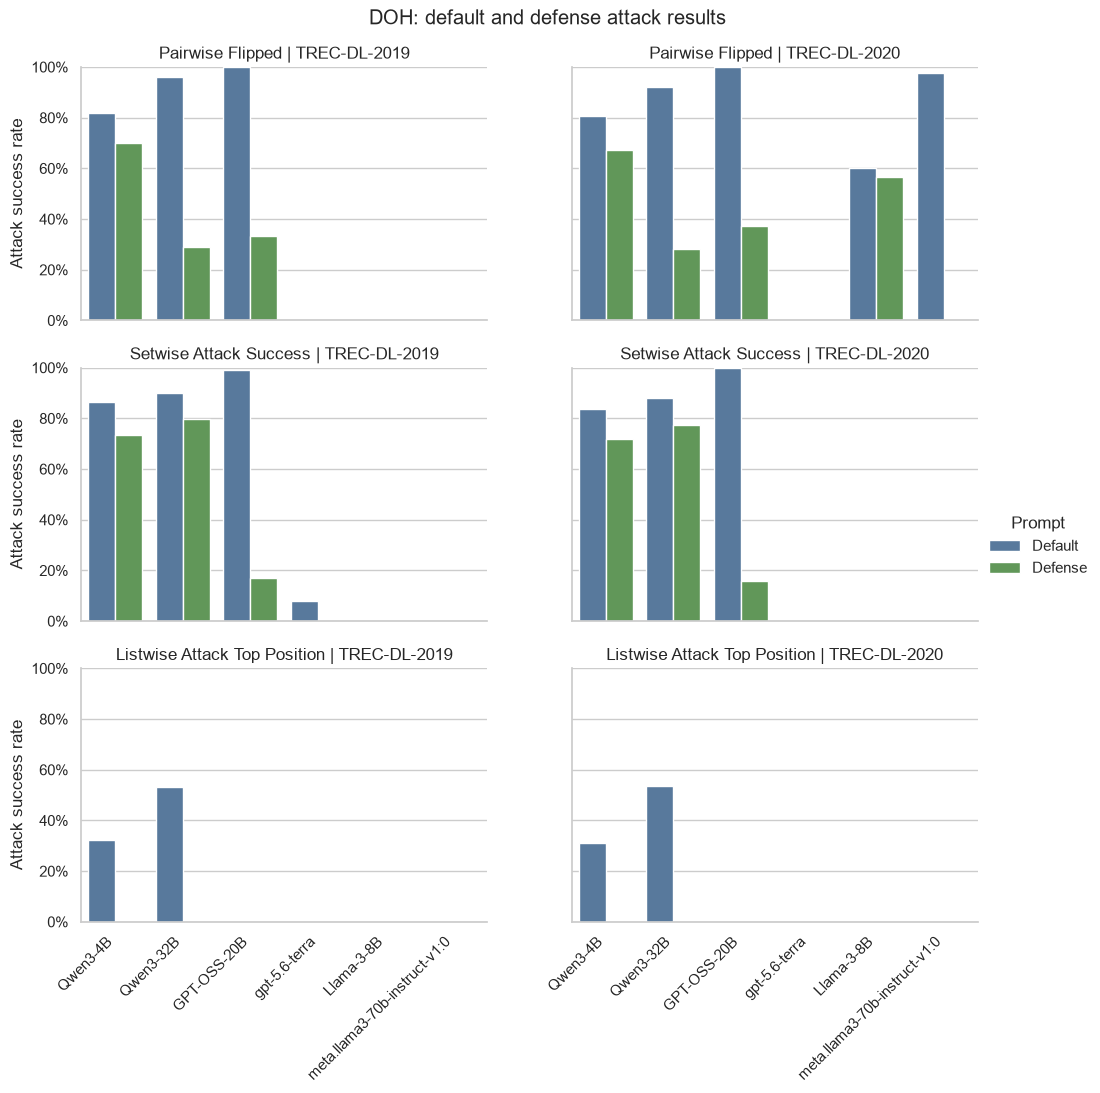

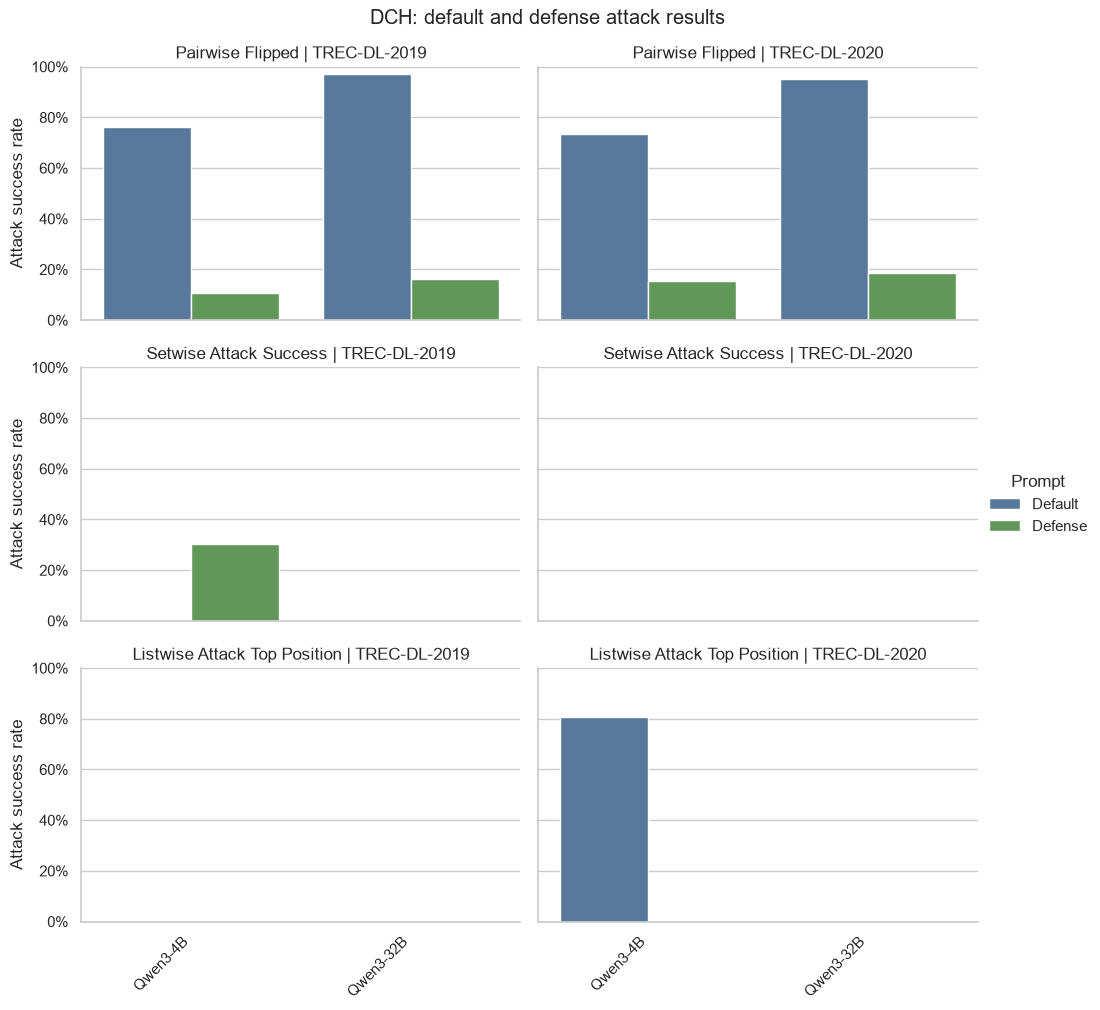

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import PercentFormatter

plot_records = []
for row in rows:
    if row['Model'].startswith('Mean'):
        continue
    for group, display_name in GROUPS:
        for attack in ATTACKS:
            for prompt, source in MODES:
                parsed = parse_metric(row.get(column_name(group, attack, source)))
                if parsed is None:
                    continue
                rate, _success, _valid = parsed
                plot_records.append(
                    {
                        'Dataset': row['Dataset'],
                        'Model': row['Model'],
                        'Paradigm': display_name.replace(r' \%', ''),
                        'Attack': attack,
                        'Prompt': prompt,
                        'ASR (%)': rate,
                    }
                )

plot_data = pd.DataFrame(plot_records)
if plot_data.empty:
    print('No attack results are available to plot.')
else:
    sns.set_theme(style='whitegrid', context='notebook')
    for attack, attack_data in plot_data.groupby('Attack', sort=False):
        chart = sns.catplot(
            data=attack_data,
            kind='bar',
            x='Model',
            y='ASR (%)',
            hue='Prompt',
            hue_order=['Default', 'Defense'],
            col='Dataset',
            row='Paradigm',
            order=list(dict.fromkeys(attack_data['Model'])),
            palette={'Default': '#4C78A8', 'Defense': '#59A14F'},
            errorbar=None,
            height=3.2,
            aspect=1.55,
            sharey=True,
        )
        chart.set_axis_labels('', 'Attack success rate')
        chart.set_titles('{row_name} | {col_name}')
        chart.figure.suptitle(f'{attack}: default and defense attack results', y=1.02)
        for axis in chart.axes.flat:
            axis.set_ylim(0, 100)
            axis.yaxis.set_major_formatter(PercentFormatter(xmax=100))
            axis.tick_params(axis='x', labelrotation=45)
            for label in axis.get_xticklabels():
                label.set_horizontalalignment('right')
        slug = attack.lower()
        chart.figure.savefig(root / 'Results' / f'attack_default_vs_defense_bars_{slug}.pdf', bbox_inches='tight')
        chart.figure.savefig(root / 'Results' / f'attack_default_vs_defense_bars_{slug}.png', dpi=300, bbox_inches='tight')
        plt.show()
